# Project 1. Denoising Network

In this project, you're going to implement a neural network to denoise images, there are several parts you need to implement to make the whole pipeline complete.

1. Dataset
2. Metrics
3. Networks
4. Training
5. Additional Question

## Dataset

In this project we are going to use an image dataset of 400 grayscale 180*180 images as our dataset, use command below to download the dataset

In [1]:
!wget "https://www.dropbox.com/scl/fi/bhvpke5p7u1xolerayx13/ImageSet-1.zip?rlkey=1oz9g3cpomt0wln0es8j9wje6&st=1fj2ksrj&dl=0" -O ImageSet.zip
!unzip -q ImageSet.zip

--2026-04-13 07:42:51--  https://www.dropbox.com/scl/fi/bhvpke5p7u1xolerayx13/ImageSet-1.zip?rlkey=1oz9g3cpomt0wln0es8j9wje6&st=1fj2ksrj&dl=0
Resolving www.dropbox.com (www.dropbox.com)... 

failed: Temporary failure in name resolution.
wget: unable to resolve host address ‘www.dropbox.com’
[ImageSet.zip]
  End-of-central-directory signature not found.  Either this file is not
  a zipfile, or it constitutes one disk of a multi-part archive.  In the
  latter case the central directory and zipfile comment will be found on
  the last disk(s) of this archive.
unzip:  cannot find zipfile directory in one of ImageSet.zip or
        ImageSet.zip.zip, and cannot find ImageSet.zip.ZIP, period.


If above link does not work, please use:
https://www.dropbox.com/scl/fi/bhvpke5p7u1xolerayx13/ImageSet-1.zip?rlkey=1oz9g3cpomt0wln0es8j9wje6&st=1fj2ksrj&dl=0
Now you should have a folder called ImageSet, and there're 400 images in it

In [2]:
!ls ImageSet | wc -l

400


Now you need to implement two classes, TrainingSet and TestingSet, you should first split your dataset into 350 images and 50 images. TrainingSet should use the 350 images to form a dataset, with each entry being a pair of image tensors, and the first image should be a noisy version of the second original image. In other words, `training_set[i]` should return `[noisy_image(=original_image + noise), original_image]`, and images should be tensors of shape $C\times H\times W$, in this case, $1\times 180\times 180$

TestingSet is the same thing with the remaining 50 images.
1. Please refer to the following code to add noise
    ```python
    def add_noise(img):
        noise = torch.randn(img.size()).mul_(self.sigma/255.0)
        noisy = img + noise
        noisy[torch.where(noisy > 1)] = 1
        noisy[torch.where(noisy < 0)] = 0
        return noisy
    ```
2. Also refer to the following code as how to read images from file to memory
    ```python
    image_path = os.path.join(ROOT_PATH, IMAGE_PATH)
    img = PIL.Image.open(image_path)
    ```

In [3]:
import torch
import os
import PIL.Image
import torchvision.transforms as transforms

class TrainingSet(torch.utils.data.Dataset):
    def __init__(self, root_path="ImageSet", sigma=10):
        self.sigma = sigma
        self.images = []
        
        all_images = sorted([
            f for f in os.listdir(root_path) 
            if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))
        ])
        
        to_tensor = transforms.ToTensor()
        
        for img_name in all_images[:350]:
            img_path = os.path.join(root_path, img_name)
            img = PIL.Image.open(img_path).convert('L')
            self.images.append(to_tensor(img))
    
    def add_noise(self, img):
        noise = torch.randn(img.size()).mul_(self.sigma / 255.0)
        noisy = img + noise
        noisy[torch.where(noisy > 1)] = 1
        noisy[torch.where(noisy < 0)] = 0
        return noisy
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        original = self.images[idx]
        noisy = self.add_noise(original)
        return [noisy, original]


class TestingSet(torch.utils.data.Dataset):
    def __init__(self, root_path="ImageSet", sigma=10):
        self.sigma = sigma
        self.images = []
        
        all_images = sorted([
            f for f in os.listdir(root_path) 
            if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))
        ])
        
        to_tensor = transforms.ToTensor()
        
        for img_name in all_images[350:]:
            img_path = os.path.join(root_path, img_name)
            img = PIL.Image.open(img_path).convert('L')
            self.images.append(to_tensor(img))
    
    def add_noise(self, img):
        noise = torch.randn(img.size()).mul_(self.sigma / 255.0)
        noisy = img + noise
        noisy[torch.where(noisy > 1)] = 1
        noisy[torch.where(noisy < 0)] = 0
        return noisy
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        original = self.images[idx]
        noisy = self.add_noise(original)
        return [noisy, original]

You can use the following code block to check if your implementation is correct, first, there should be **no error**, second, the shape of image should be **`[1, 180, 180]`**, and finally, in the drawing area, the **left hand side image should be noisier than the right hand side image**, but they should be images of the same thing.

Shape of image: torch.Size([1, 180, 180])


Text(0.5, 1.0, 'original example')

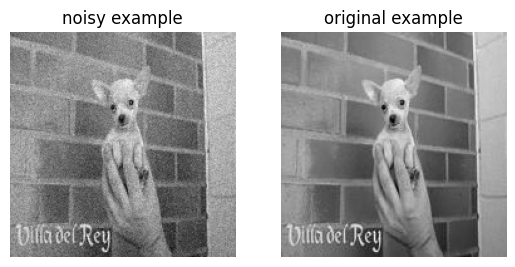

In [4]:
training_set = TrainingSet()
testing_set = TestingSet()
assert len(training_set) == 350
assert len(testing_set) == 50

print(f'Shape of image: {training_set[0][0].shape}')

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1,2)
axes[0].imshow(training_set[0][0][0], cmap='gray')
axes[0].axis('off')
axes[0].set_title('noisy example')
axes[1].imshow(training_set[0][1][0], cmap='gray')
axes[1].axis('off')
axes[1].set_title('original example')

## Metrics
To quantify how noisy an image is compared to the original one, we're going to use PSNR, please implement a function `psnr` to return the psnr score.

Refer to https://en.wikipedia.org/wiki/Peak_signal-to-noise_ratio about the formula of PSNR

Note:
1. higher PSNR means noise is relatively smaller, the PSNR of the original image is positive infinity, because the noise is zero.
2. the psnr is a symetric function, meaning the psnr of a noisy image with respect to the original one is the same as the psnr of the original image with respect to the noisy one.

In [5]:
# implement your psnr function
def psnr(original, noisy):
    mse = torch.mean((original - noisy) ** 2)
    if mse == 0:
        return float('inf')
    return 20 * torch.log10(1.0 / torch.sqrt(mse))

# from metrics import psnr # to skip this part

Run the following code to check if the implementation is correct, the expected output should be about 7.96

In [6]:
import torch
test_original = torch.tensor([[0.1, 0.2], [0.3, 0.4]])
test_noisy = torch.tensor([[0.5, 0.6], [0.7, 0.8]])
print(f'PSNR score: {psnr(test_original, test_noisy)}')

PSNR score: 7.958800315856934


And we can calculate the psnr score for the noisy image pair we showed above, the score should be aroud 28, but there could be exception.

In [7]:
print(f'PSNR score for example images: {psnr(training_set[0][1], training_set[0][0])}')

PSNR score for example images: 28.09053611755371


## Network
Now that we got dataset ready and metrics ready, we start preparing the network. You need to define a class `DenoiseNetwork` as your network class.

The goal of your network is to take the noisy image as input and output the predicted **noise**. First of all, the input and the output of the network should have the same size, the main idea is to predict the original image first by going through several CNN layers, and then use the input noisy image to deduct predicted original image to get the noise, the pseudo code should be like:
```python
class DenoiseNetwork(nn.Module):
    def __init__(self):
        define some cnn layers and other necessary components
    
    def forward(self, x):
        predicted_original_image = cnn_network(x)
        noise = x - predicted_original_image
        return noise
```
Then calculate the mean squared error between the predicted noise and the truth noise as our loss, and try to minimize it.

Tips:
1. you can use nn.MSELoss as your loss function
2. Use Adam instead of SGD as your optimizer, initial learning rate set to 0.001
3. Use `torch.nn.init.orthogonal_` to initialize the `weight` of your cnn layers as orthogonal matrices, and use `torch.nn.init.constant_` to fill the `bias` of your cnn layers with `0`s.
4. Try dropout, batchnorm etc. to improve the results (training speed, restored results etc.)

In [8]:
import torch.nn as nn
import torch.nn.init as init

class DenoiseNetwork(nn.Module):
    def __init__(self, depth=13, channels=64):
        super(DenoiseNetwork, self).__init__()
        
        layers = []
        # Layer 1: no BN
        layers += [nn.Conv2d(1, channels, kernel_size=3, padding=1, bias=True),
                   nn.ReLU(inplace=True)]
        
        # Layers 2 to depth-1: Conv + BN + ReLU
        for _ in range(depth - 2):
            layers += [nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False),
                       nn.BatchNorm2d(channels),
                       nn.ReLU(inplace=True)]
        
        # Last layer: no BN, no ReLU
        layers += [nn.Conv2d(channels, 1, kernel_size=3, padding=1, bias=False)]
        
        self.network = nn.Sequential(*layers)
        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                init.orthogonal_(m.weight)
                if m.bias is not None:
                    init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm2d):
                init.constant_(m.weight, 1)
                init.constant_(m.bias, 0)

    @property
    def device(self):
        return next(self.parameters()).device

    def forward(self, x):
        predicted_original = self.network(x)
        noise = x - predicted_original
        return noise

net = DenoiseNetwork().cuda()

Here're some basic tests to see if your network can at least run through an example image, this is expected to produce no error.

In [9]:
example_batch = training_set[0][0].unsqueeze(0)
assert net(example_batch.cuda()).shape == example_batch.shape

Now we need a quantitative score to indicate how well a network performs. Previously we have defined the psnr function, but it only calculates psnr of an image pair, we need to calculate two scores to see how well the network denoises, the first is the mean psnr score of all noisy images, which indicates how noisy these unprocessed images are, and then assume we have the network ready, we can use the network to predict the noise, and deduct the noise from the noisy images to produce restored images, then we calculate the mean psnr score of these restored images with respect to the original images, and this score indicate how noisy the restored images are. If everything works out fine, we should be able to observe a higher psnr on the restored images.

You need to define a `mean_psnr` function that takes a dataset and a network as input and calculate the mean psnr scores of original noisy images across the whole dataset and mean psnr of restored images processed by the network.

In [10]:
# implement your mean_psnr function
def mean_psnr(testset, net):
    net.eval()
    
    total_psnr_original = 0.0
    total_psnr_restored = 0.0
    
    with torch.no_grad():
        for noisy, original in testset:
            # Add batch dimension for network input: 1x1x180x180
            noisy_input = noisy.unsqueeze(0).to(net.device)
            
            # Predict noise and restore image
            predicted_noise = net(noisy_input)
            restored = noisy_input - predicted_noise
            
            # Clamp restored image to valid range
            restored = restored.squeeze(0).cpu().clamp(0, 1)
            
            # Accumulate PSNR scores
            total_psnr_original += psnr(original, noisy).item()
            total_psnr_restored += psnr(original, restored).item()
    
    n = len(testset)
    mean_psnr_original = total_psnr_original / n
    mean_psnr_after = total_psnr_restored / n
    
    net.train()
    
    return mean_psnr_original, mean_psnr_after

# from metrics import mean_psnr # to skip this part
# note: to use this mean_psnr function, your network needs to implement a property `device`

We can calculte the mean psnr on `testing_set`

In [11]:
mean_psnr(testing_set, net)

(28.21233081817627, 6.085430116653442)

If your code is correct, you should see the mean psnr of original images should be around 28, and the psnr of network processed images is much smaller, which means, a randomly initialzed network adds even more noise, you should see this by displaying.

Text(0.5, 1.0, 'restored')

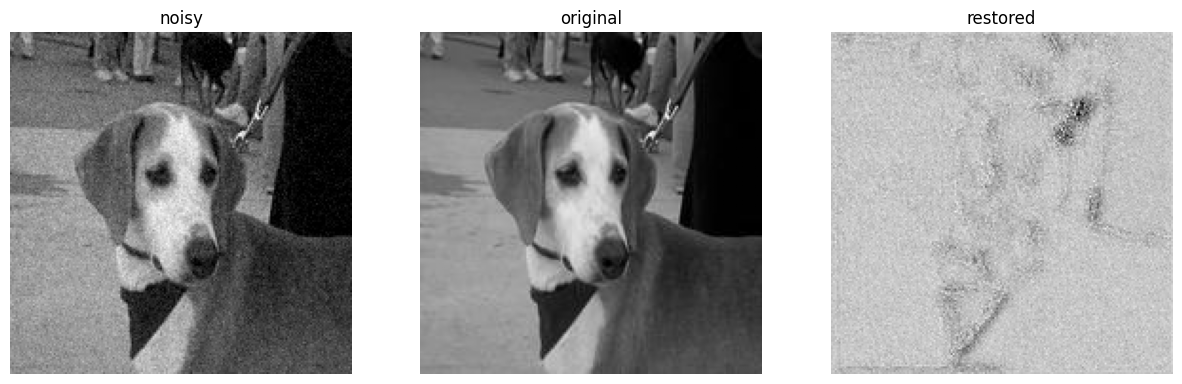

In [12]:
noisy_image, original_image = testing_set[0]
noisy_image = noisy_image.cuda()
predicted_noise = net(noisy_image.unsqueeze(0)).squeeze(0)
restored_image = noisy_image - predicted_noise

fig, axes = plt.subplots(1,3)
fig.set_figwidth(15)
axes[0].imshow(noisy_image[0].cpu(), cmap='gray')
axes[0].axis('off')
axes[0].set_title('noisy')
axes[1].imshow(original_image[0], cmap='gray')
axes[1].axis('off')
axes[1].set_title('original')
axes[2].imshow(restored_image[0].cpu().detach(), cmap='gray')
axes[2].axis('off')
axes[2].set_title('restored')

## Training
Now that we got everything ready, we should start training, in the next section, you need to implement the training process, that includes defining criteria, setting up optimizer, going through several epochs to train the network, during the training, you should also analyze the psnr scores to see how it goes in terms of quantified performance.

Checklist:
1. define dataloader, recommend batch size starting from 32
2. criteria
3. optimizer
4. (optional) consider using functions in torch.optim.lr_scheduler to adjust your learning rate, because smaller learning rate might work better in the later period of training, similar to fine adjustment. Reference: https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
5. during each iteration, you need to 1. get the noisy image and the original image 2. calculate predicted noise from network, use MSE to calculate the distance between predicted noise and true noise 3. reset gradients to zero 3. use the distance as loss to backward the network to get gradients 4. perform learning with the gradients using optimizer
6. From time to time (e.g. each epoch), calculate PSNR on testing_set

Epoch [  1/100] Loss: 0.088164 | LR: 0.001000 | PSNR noisy: 28.22 dB | PSNR restored: 11.09 dB
Epoch [  2/100] Loss: 0.011237 | LR: 0.001000 | PSNR noisy: 28.22 dB | PSNR restored: 13.99 dB
Epoch [  3/100] Loss: 0.006956 | LR: 0.001000 | PSNR noisy: 28.21 dB | PSNR restored: 15.14 dB
Epoch [  4/100] Loss: 0.006340 | LR: 0.001000 | PSNR noisy: 28.22 dB | PSNR restored: 21.13 dB
Epoch [  5/100] Loss: 0.006811 | LR: 0.001000 | PSNR noisy: 28.21 dB | PSNR restored: 22.70 dB
Epoch [  6/100] Loss: 0.006017 | LR: 0.001000 | PSNR noisy: 28.21 dB | PSNR restored: 22.31 dB
Epoch [  7/100] Loss: 0.005180 | LR: 0.001000 | PSNR noisy: 28.22 dB | PSNR restored: 23.90 dB
Epoch [  8/100] Loss: 0.006216 | LR: 0.001000 | PSNR noisy: 28.22 dB | PSNR restored: 24.34 dB
Epoch [  9/100] Loss: 0.005214 | LR: 0.001000 | PSNR noisy: 28.22 dB | PSNR restored: 24.30 dB
Epoch [ 10/100] Loss: 0.004867 | LR: 0.001000 | PSNR noisy: 28.21 dB | PSNR restored: 24.01 dB
Epoch [ 11/100] Loss: 0.003402 | LR: 0.001000 | PS

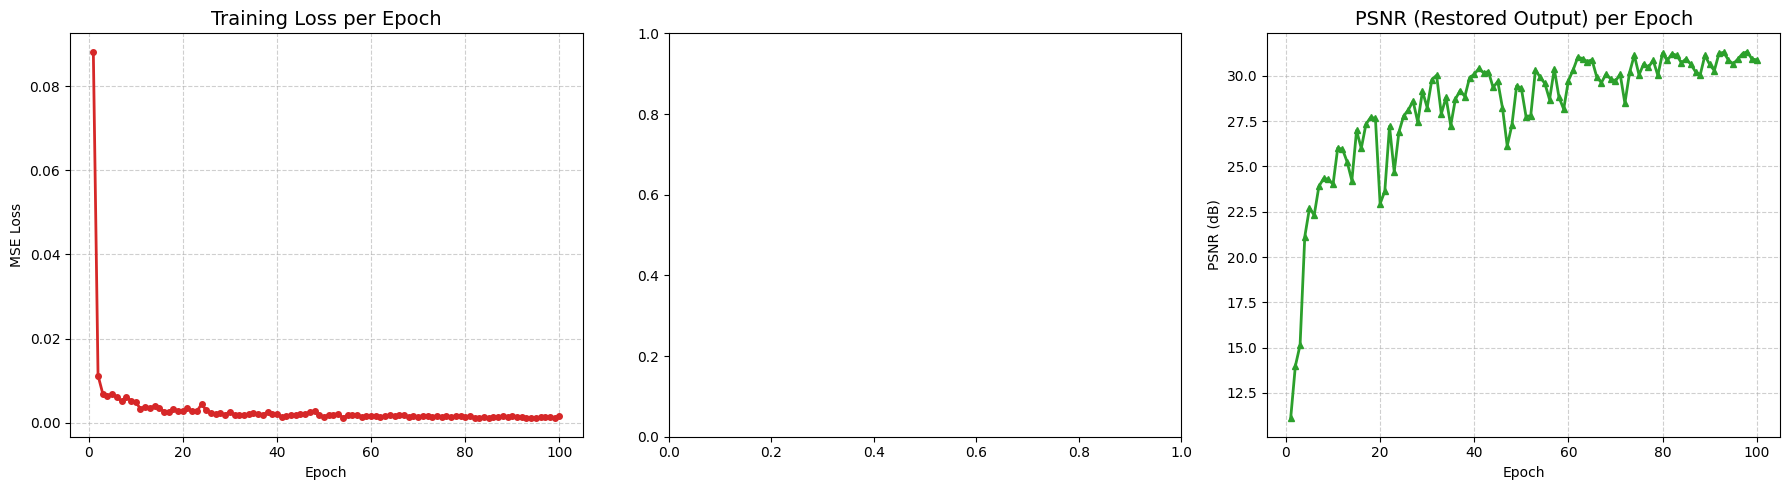

In [14]:
from torch.utils.data import DataLoader
import torch.optim as optim
import matplotlib.pyplot as plt

# 1. Dataloader
train_loader = DataLoader(training_set, batch_size=32, shuffle=True)

# 2. Criterion
criterion = nn.MSELoss()

# 3. Optimizer
optimizer = optim.Adam(net.parameters(), lr=0.001)

# 4. Learning rate scheduler - halves LR every 30 epochs
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.5)

# 5. Tracking lists
epochs_list = []
loss_list = []
psnr_noisy_list = []
psnr_restored_list = []

# 6. Training loop
num_epochs = 100

for epoch in range(num_epochs):
    net.train()
    epoch_loss = 0.0

    for noisy, original in train_loader:
        noisy = noisy.cuda()
        original = original.cuda()

        true_noise = noisy - original
        predicted_noise = net(noisy)
        loss = criterion(predicted_noise, true_noise)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    scheduler.step()

    avg_loss = epoch_loss / len(train_loader)
    psnr_noisy, psnr_restored = mean_psnr(testing_set, net)
    current_lr = scheduler.get_last_lr()[0]

    # Append metrics to lists
    epochs_list.append(epoch + 1)
    loss_list.append(avg_loss)
    psnr_noisy_list.append(psnr_noisy)
    psnr_restored_list.append(psnr_restored)

    print(f"Epoch [{epoch+1:3d}/{num_epochs}] "
          f"Loss: {avg_loss:.6f} | "
          f"LR: {current_lr:.6f} | "
          f"PSNR noisy: {psnr_noisy:.2f} dB | "
          f"PSNR restored: {psnr_restored:.2f} dB")


# 7. Plot all 3 graphs
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Plot 1: Epochs vs Loss ---
axes[0].plot(epochs_list, loss_list, color='tab:red', linewidth=2, marker='o', markersize=4)
axes[0].set_title('Training Loss per Epoch', fontsize=14)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].grid(True, linestyle='--', alpha=0.6)

# --- Plot 3: Epochs vs PSNR Restored ---
axes[2].plot(epochs_list, psnr_restored_list, color='tab:green', linewidth=2, marker='^', markersize=4)
axes[2].set_title('PSNR (Restored Output) per Epoch', fontsize=14)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('PSNR (dB)')
axes[2].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('training_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

Now that your net is ready, we can re do the demonstration.

Text(0.5, 1.0, 'restored')

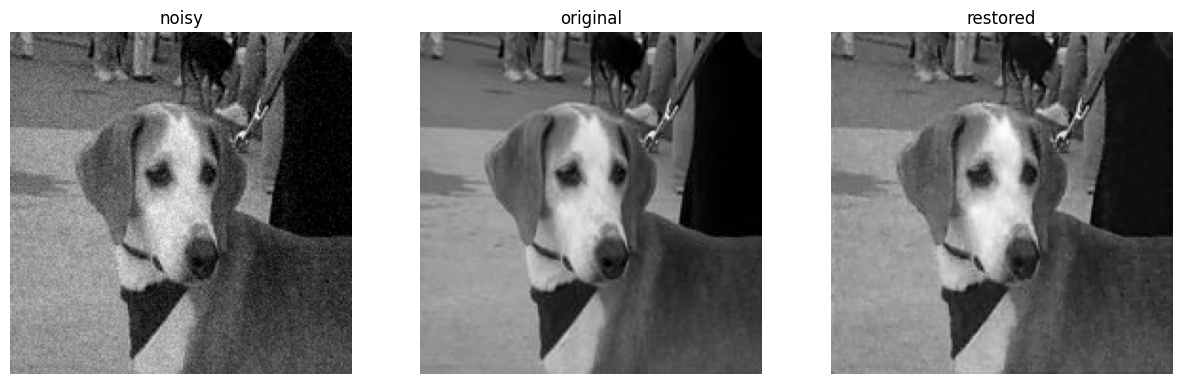

In [15]:
noisy_image, original_image = testing_set[0]
noisy_image = noisy_image.cuda()
predicted_noise = net(noisy_image.unsqueeze(0)).squeeze(0)
restored_image = noisy_image - predicted_noise

fig, axes = plt.subplots(1,3)
fig.set_figwidth(15)
axes[0].imshow(noisy_image[0].cpu(), cmap='gray')
axes[0].axis('off')
axes[0].set_title('noisy')
axes[1].imshow(original_image[0], cmap='gray')
axes[1].axis('off')
axes[1].set_title('original')
axes[2].imshow(restored_image[0].cpu().detach(), cmap='gray')
axes[2].axis('off')
axes[2].set_title('restored')

The network I trained here is a simple 3-layer low number of channel cnn network, and you can see it's already starting to work. Now try adjust some parameters/network structure to make it work even better. Write down your analysis to make a pdf report.

You need to submit two files, this ipynb file and a pdf report with your analysis.

# Additional Question

In this additional question, you need to test on noise different from your training set. In the previous project, you were asked to use Gaussian noise for training, and you also used Gaussian noise when testing.

In this additional question, you are asked to test your trained model using speckle noise. A simple model of Speckle noise is multiplicative noise, which means that the noise is generated by multiplying each pixel value of the image by a random number. This random number is usually drawn from a distribution with a mean of 1 to ensure that noise averaging does not brighten or darken the image.

Below is a Python function that simply implements Speckle noise. This implementation first generates a random noise matrix of the same size as the input image, with values drawn from a normal distribution with mean 1 and standard deviation sigma. This noise matrix is then multiplied by the original image to generate an image with Speckle noise. Finally, the result is constrained to the range 0 to 1 to keep the pixel values valid.

```python
def add_speckle_noise(img, sigma=0.1):
    noise = torch.randn(img.size()) * sigma + 1.0
    noisy_img = img * noise
    noisy_img.clamp_(0, 1)
    return noisy_img
```
You are asked to do the following:

1. First, you are asked to find appropriate sigma values so that the resulting image is visually similar to your training noise. To make your results more general, it is best to choose 3 possible values. (5%)

2. Test your model on these speckle noises using the same model trained above. Compare the PSNR tested on speckle noise with the PSNR tested on Gaussian noise. Show your results in a table. (5%)

3. Finally, draw your conclusion in the pdf report. Can a model trained on Gaussian noise handle speckle noise? To what extent can it be handled? (5%)


Speckle sigma sweep (target PSNR ≈ 20.45 dB):
Sigma      Mean PSNR (dB)      
------------------------------
0.05       32.1321             
0.08       28.1141             
0.10       26.2227             
0.12       24.6994             
0.15       22.8297             
0.20       20.4490             
0.25       18.6126             
0.30       17.1522             

Chosen speckle sigmas: [0.15, 0.2, 0.25]

Noise Type                Sigma      PSNR Noisy (dB)        PSNR Restored (dB)    
Gaussian                  25 (÷255)  28.2201                29.3505               
Speckle                   0.15       22.8134                25.3472               
Speckle                   0.20       20.4385                22.9163               
Speckle                   0.25       18.6229                21.0454               


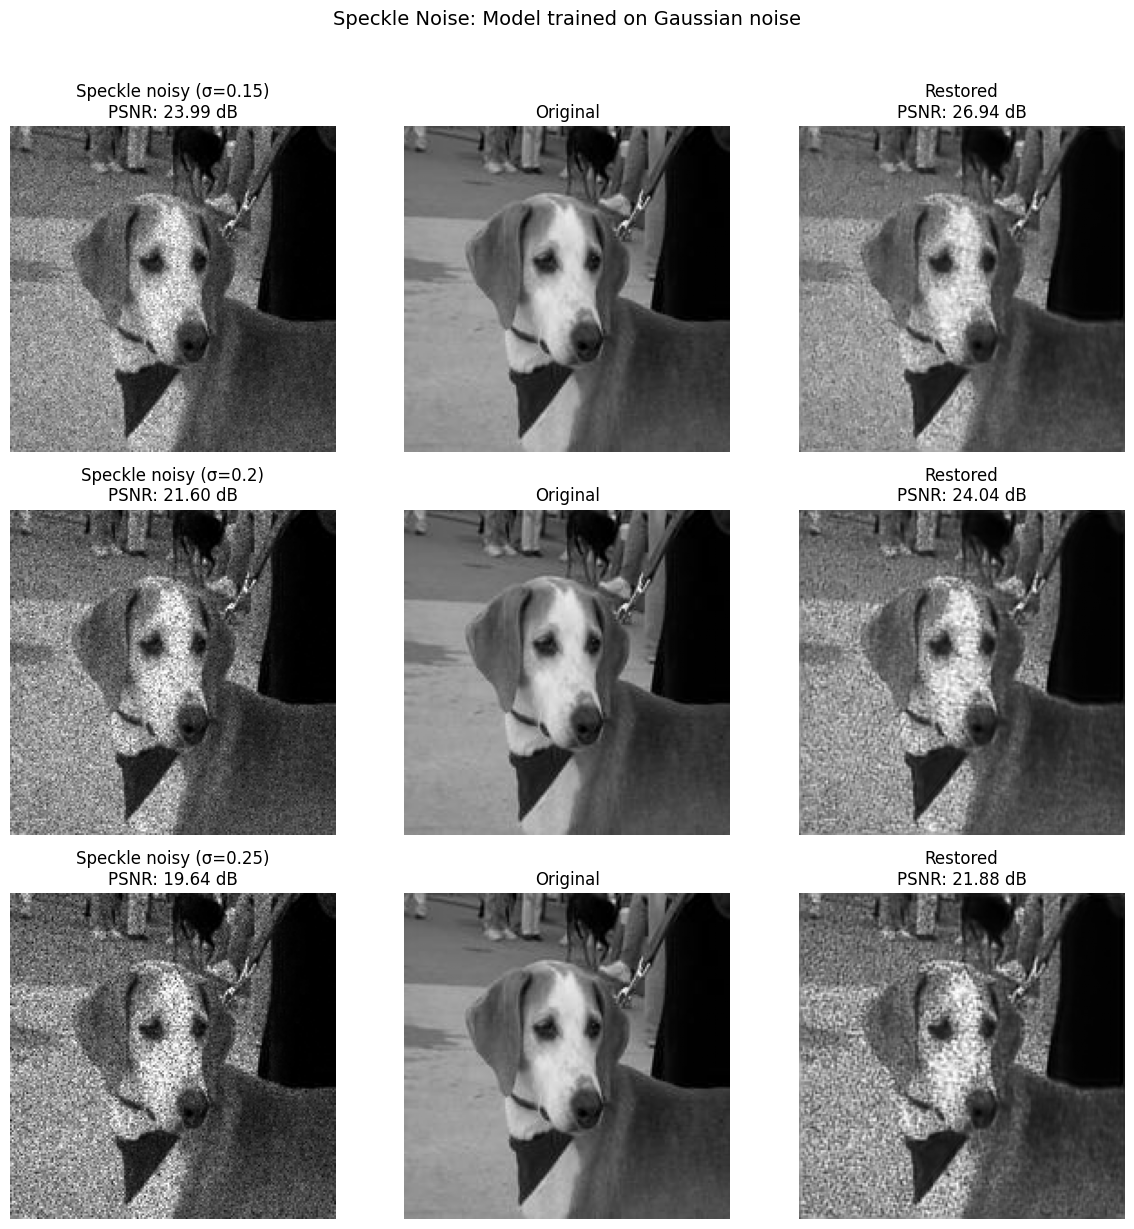

In [ ]:
def add_speckle_noise(img, sigma=0.1):
    noise = torch.randn(img.size()) * sigma + 1.0
    noisy_img = img * noise
    noisy_img.clamp_(0, 1)
    return noisy_img


# ── 1. Find sigma values that give visually similar noise to Gaussian σ=25 ──

# The Gaussian training noise had PSNR ≈ 20.45 dB
# We'll sweep speckle sigmas and find which ones give similar PSNR on the test set

import numpy as np

speckle_sigmas = [0.05, 0.08, 0.10, 0.12, 0.15, 0.20, 0.25, 0.30]

print("Speckle sigma sweep (target PSNR ≈ 20.45 dB):")
print(f"{'Sigma':<10} {'Mean PSNR (dB)':<20}")
print("-" * 30)

sigma_psnr_pairs = []
for sigma in speckle_sigmas:
    total = 0.0
    for noisy, original in testing_set:
        speckle_noisy = add_speckle_noise(original, sigma=sigma)
        total += psnr(original, speckle_noisy).item()
    mean = total / len(testing_set)
    sigma_psnr_pairs.append((sigma, mean))
    print(f"{sigma:<10.2f} {mean:<20.4f}")


# ── 2. Choose 3 sigmas closest to the Gaussian PSNR baseline ──

gaussian_psnr_baseline = 20.45
sigma_psnr_pairs.sort(key=lambda x: abs(x[1] - gaussian_psnr_baseline))
chosen_sigmas = [s for s, _ in sigma_psnr_pairs[:3]]
chosen_sigmas.sort()
print(f"\nChosen speckle sigmas: {chosen_sigmas}")


# ── 3. Evaluate trained model on speckle noise ──

class SpeckleTestingSet(torch.utils.data.Dataset):
    def __init__(self, base_dataset, sigma):
        self.base = base_dataset
        self.sigma = sigma

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        _, original = self.base[idx]   # use clean original, not Gaussian-noisy
        speckle_noisy = add_speckle_noise(original, sigma=self.sigma)
        return speckle_noisy, original


def mean_psnr_speckle(testset, net):
    """Same as mean_psnr but testset already contains speckle-noisy images."""
    net.eval()
    total_noisy = 0.0
    total_restored = 0.0

    with torch.no_grad():
        for noisy, original in testset:
            noisy_input = noisy.unsqueeze(0).to(net.device)
            predicted_noise = net(noisy_input)
            restored = (noisy_input - predicted_noise).squeeze(0).cpu().clamp(0, 1)

            total_noisy    += psnr(original, noisy).item()
            total_restored += psnr(original, restored).item()

    n = len(testset)
    net.train()
    return total_noisy / n, total_restored / n


# ── 4. Collect results into a table ──

print("\n" + "=" * 75)
print(f"{'Noise Type':<25} {'Sigma':<10} {'PSNR Noisy (dB)':<22} {'PSNR Restored (dB)':<22}")
print("=" * 75)

# Gaussian baseline (already computed during training)
gauss_noisy, gauss_restored = mean_psnr(testing_set, net)
print(f"{'Gaussian':<25} {'25 (÷255)':<10} {gauss_noisy:<22.4f} {gauss_restored:<22.4f}")

# Speckle results
for sigma in chosen_sigmas:
    speckle_set = SpeckleTestingSet(testing_set, sigma=sigma)
    sp_noisy, sp_restored = mean_psnr_speckle(speckle_set, net)
    print(f"{'Speckle':<25} {sigma:<10.2f} {sp_noisy:<22.4f} {sp_restored:<22.4f}")

print("=" * 75)


# ── 5. Visual comparison for one sample image ──

fig, axes = plt.subplots(len(chosen_sigmas), 3, figsize=(12, 4 * len(chosen_sigmas)))

for row, sigma in enumerate(chosen_sigmas):
    _, original = testing_set[0]
    speckle_noisy = add_speckle_noise(original, sigma=sigma)

    noisy_input = speckle_noisy.unsqueeze(0).cuda()
    net.eval()
    with torch.no_grad():
        predicted_noise = net(noisy_input)
    restored = (noisy_input - predicted_noise).squeeze(0).cpu().clamp(0, 1)

    axes[row, 0].imshow(speckle_noisy[0], cmap='gray')
    axes[row, 0].axis('off')
    axes[row, 0].set_title(f'Speckle noisy (σ={sigma})\nPSNR: {psnr(original, speckle_noisy):.2f} dB')

    axes[row, 1].imshow(original[0], cmap='gray')
    axes[row, 1].axis('off')
    axes[row, 1].set_title('Original')

    axes[row, 2].imshow(restored[0], cmap='gray')
    axes[row, 2].axis('off')
    axes[row, 2].set_title(f'Restored\nPSNR: {psnr(original, restored):.2f} dB')

plt.suptitle('Speckle Noise: Model trained on Gaussian noise', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Marking Scheme:


*   Code implementation: 35%


> * Dataset 5% (Download the dataset correctly and preprocess it appropriately for use as the training and testing sets.)
> * Metrics 5% (Set and use appropriate metrics to evaluate the model.)
> * Network 5% (only 5% because network overlaps with results, you need to adjust the network to improve the results anyway.)
> * Training code 10% (The training code executes correctly, and the code structure is clear and well organized.)
> * reasonably good results 10% (The model reaches the target training outcome with satisfactory performance.)


*   PDF report: 25%

> * Basic results demonstration (network introduction, denoising results showcase) 10%
> * Analysis and improvements 15% (You're supposed to clarify how do you make the network work, e.g. if you encounter some issues, what do you do to address them)


*   Addtional question: 15%

> * Find appropriate sigma values (5%)
> * Test your model on these speckle noises and report them in a table (5%)
> * Draw your conclusion: Can a model trained on Gaussian noise handle speckle noise? To what extent can it be handled? (5%)


*   Oral question: 25%

> * After the assignment submission, each group will be asked one question related to the assignment during the tutorial. This is a group-based activity, and each group may nominate one member to answer the question. All group members must attend the session.

